Before we start to work with entire data sets next week, we first have to become familiar with basic geometric objects (primitives): in the centre of this week’s lesson stand points, lines, and polygons.

# Why Python for GIS?
Most desktop GIS (e.g., QGIS, ESRI ArcGIS) have language bindings or programming interfaces for Python: that means that you can write Python programs that interact with data, libraries, and user interface of these applications, and create custom plugins to extend their functionality. Beyond that, here are powerful Python packages for virtually any task regarding spatial data management and spatial analysis.

## GIS packages available in Python
* Data analysis and visualization
  * Numpy
  * Pandas
  * SciPy
  * Matplotlib
  * Bokeh: interactive vis for the web (also maps)
  * Plotly: Interactive visualizations (also maps) for the web (commercial - free for educational purposes)
* GIS:

  GDAL: Fundamental package for processing vector and raster data formats (many modules below depend on this). Used for raster processing.

  Geopandas: Working with geospatial data in Python made easier, combines the capabilities of pandas and shapely.

  Shapely: Python package for manipulation and analysis of planar geometric objects (based on widely deployed GEOS

  Fiona: Reading and writing spatial data (alternative for geopandas).

  Pyproj: Performs cartographic transformations and geodetic computations (based on PROJ.4).

  Pysal: Library of spatial analysis functions written in Python.

  Geopy: Geocoding library: coordinates to address <-> address to coordinates.

  Contextily: Add background basemaps for your (static) map visualizations

  GeoViews: Interactive Maps for the web.

  Geoplot: High-level geospatial data visualization library for Python.

  Dash: Dash is a Python framework for building analytical web applications.

  OSMnx: Python for street networks. Retrieve, construct, analyze, and visualize street networks from OpenStreetMap

  Networkx: Network analysis and routing in Python (e.g. Dijkstra and A* -algorithms), see this post.

  Cartopy: Make drawing maps for data analysis and visualisation as easy as possible.

  Scipy.spatial: Spatial algorithms and data structures.

  Rtree: Spatial indexing for Python for quick spatial lookups.

  Rasterio: Clean and fast and geospatial raster I/O for Python.

  RSGISLib: Remote Sensing and GIS Software Library for Python.

# Shapely and Geometry Objects

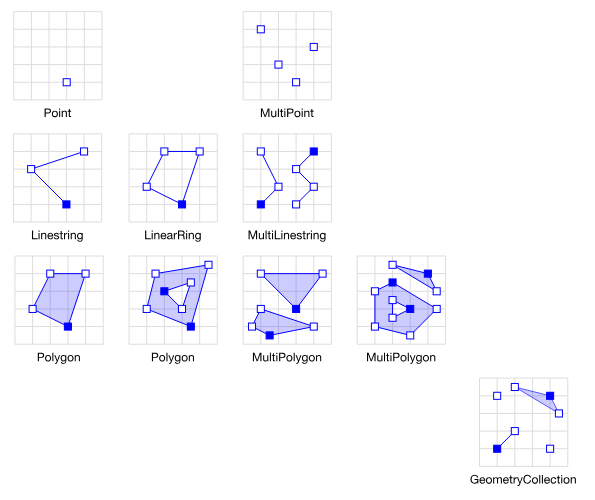

## Geometric objects are described and constructed by coordinate tuples

Even more fundamental than that, coordinate tuples are what is used to define the geometric fundamentals point, line, and polygon. Coordinate tuples typically are either two-dimensional (x, y), or three-dimensional (x, y, z).

### Using shapely to create, access, manipulate and analyse geometric objects
Shapely can perform many useful operations on geometries, and provides a range of attributes of geometries. For instance, you can:

create lines and polygons from a set of points

calculate the area, length, perimeter, etc., of geometries

perform geometric operations on a set of geometries, for instance, merging (union), subtracting (difference), or calculating the distance between geometries.

query the relationship between geometries, i.e., find out whether two geometries intersect, touch, cross, etc.

#### Creating Point and accessing their props


In [1]:
# Import `shapely.geometry.Point` class
from shapely.geometry import Point

# Create `Point` objects:
point1 = Point(2.2, 4.2)
point2 = Point(7.2, -25.1)
point3 = Point(9.26, -2.456)
point4_3D = Point(9.26, -2.456, 0.57)

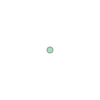

In [2]:
point1

In [3]:
print(point1)

POINT (2.2 4.2)


In [6]:
dist = point1.distance(point2)
dist

29.723559679150142

Caution:
Shapely geometries are, by design, agnostic (unaware) of the reference system used to represent them. Distances and surface area calculated using the built-in shapely methods will always:
assume a flat, Cartesian, Euclidean space, and

return the calculated value in the unit of the coordinates (e.g., meters, or degrees).

This is perfectly fine for small-scale geo-spatial operations, if you keep yourself aware of the expected output unit. Most packages built on top of shapely, for instance GeoPandas, which we will get to know in lesson 2, bring their own functions and take the coordinate reference system into consideration.

## Lines

In [7]:
# import the LineString class
from shapely.geometry import LineString

# Create a LineString from our Point objects
line = LineString([point1, point2, point3])

# Create a LineString from a list of coordinates:
# (with the same coordinate values as the points, so results should be identical)
line2 = LineString([(2.2, 4.2), (7.2, -25.1), (9.26, -2.456)])

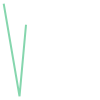

In [8]:
line

In [10]:
from shapely.geometry import Polygon

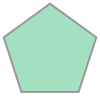

In [11]:
Polygon([(30, 2.01), (31.91, 0.62), (31.18, -1.63), (28.82, -1.63), (28.09, 0.62)])

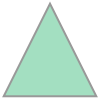

In [12]:

Polygon([(0,0), (2,4), (4,0)])

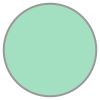

In [14]:
# Circle (using a buffer around a point)
point = Point((0,0))
point.buffer(8)

## Collections

In [16]:
from shapely.geometry import MultiPoint, MultiLineString, MultiPolygon

# Create a MultiPoint object of our points 1,2 and 3
multipoint = MultiPoint([point1, point2, point3])

# We can also create a MultiLineString with two lines
line1 = LineString([point1, point2])
line2 = LineString([point2, point3])
multiline = MultiLineString([line1, line2])

print(multipoint)
print(multiline)

MULTIPOINT ((2.2 4.2), (7.2 -25.1), (9.26 -2.456))
MULTILINESTRING ((2.2 4.2, 7.2 -25.1), (7.2 -25.1, 9.26 -2.456))


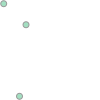

In [17]:
multipoint

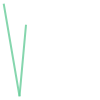

In [19]:
multiline

### Convex hull and envelope

A ‘convex hull’ refers to the smallest possible convex polygon that can contain a geometry or a set of geometries. Alongside bounding boxes, convex hulls are useful to describe the extent of data sets.

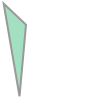

In [21]:
multipoint.convex_hull

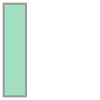

In [22]:
multipoint.envelope

# Excercise 1